<a href="https://colab.research.google.com/github/KuoZiyun/Python/blob/main/%E3%80%8CMacro_Rent_Labor_Analysis%E3%80%8D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step 1. 讀取資料並檢視

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Google 雲端硬碟已掛載成功！現在您可以從 '/content/drive' 存取您的檔案。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google 雲端硬碟已掛載成功！現在您可以從 '/content/drive' 存取您的檔案。


##A. 找到資料讀入python, 並用指令探索

###A1. 解釋變數

In [ ]:
import pandas as pd

# 讀入資料，檔名是 zillow_rent.csv
df0 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Python與經濟金融應用/zillow_rent.csv')

In [ ]:
# 指令 1: df.shape, 看資料規模 (列數 rows, 欄數 columns)。
df0.shape

(707, 135)

In [ ]:
# 指令 2: df.columns, 看有哪些欄位名稱。
df0.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       '2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30', '2015-05-31',
       ...
       '2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30', '2025-05-31',
       '2025-06-30', '2025-07-31', '2025-08-31', '2025-09-30', '2025-10-31'],
      dtype='object', length=135)

In [ ]:
# 指令 3: df.dtypes, 看資料型態, 數值是否誤存為字串 (Object) 。
df0.dtypes

,0
RegionID,int64
SizeRank,int64
RegionName,object
RegionType,object
StateName,object
...,...
2025-06-30,float64
2025-07-31,float64
2025-08-31,float64
2025-09-30,float64


In [ ]:
# 指令 4: df.isna().sum() ,檢查缺失值。
df0.isna().sum()

,0
RegionID,0
SizeRank,0
RegionName,0
RegionType,0
StateName,1
...,...
2025-06-30,81
2025-07-31,75
2025-08-31,65
2025-09-30,47


In [ ]:
# 指令 5: df.head() ,看前五筆資料。
df0.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,1164.805927,1171.136726,1179.812677,1188.754760,1197.580151,...,1907.881861,1917.211710,1929.474463,1938.907827,1946.045220,1950.907629,1953.050444,1953.533991,1952.050075,1948.708033
1,394913,1,"New York, NY",msa,NY,2236.846063,2251.501965,2269.987984,2289.332030,2303.951188,...,3224.984612,3243.454165,3273.056839,3303.707881,3331.069676,3362.757608,3392.266330,3413.333733,3410.432125,3397.903293
2,753899,2,"Los Angeles, CA",msa,CA,1761.871581,1773.071117,1788.065047,1803.355323,1818.396065,...,2871.016877,2893.329888,2917.051681,2915.965206,2919.777391,2924.061198,2926.492700,2927.792645,2927.121443,2924.884110
3,394463,3,"Chicago, IL",msa,IL,1341.017779,1347.973222,1357.967496,1366.921287,1376.295747,...,1975.864028,1992.854981,2010.426073,2031.988128,2051.148618,2069.356824,2080.192420,2083.993205,2082.427779,2076.789127
4,394514,4,"Dallas, TX",msa,TX,1066.712642,1071.569949,1079.056262,1090.463624,1099.855135,...,1665.951348,1673.276725,1682.741809,1692.738538,1695.424062,1696.307700,1693.127850,1689.310560,1684.573082,1678.471598


In [ ]:
# 指令 6: df.sample(5) ,隨機抽樣看五筆。
df0.sample(5)

,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
67,394908,68,"New Haven, CT",msa,CT,1093.135237,1094.279696,1107.007186,1111.40656,1114.863687,...,1885.116155,1907.696609,1915.951589,1924.617238,1935.177592,1939.047450,1948.256252,1943.486983,1950.585754,1955.441511
596,395155,646,"Thomasville, GA",msa,GA,NaN,NaN,NaN,NaN,NaN,...,1489.422650,1512.568168,1545.071952,NaN,1547.461478,1526.751842,1538.749418,1575.682357,1559.266562,1556.805556
661,394713,768,"Jackson, WY",msa,WY,NaN,NaN,NaN,NaN,NaN,...,3440.093538,3495.032787,3516.632482,3558.278767,3588.514190,3626.216993,3610.808959,3594.483359,3586.945002,3638.194444
704,394996,915,"Portales, NM",msa,NM,NaN,NaN,NaN,NaN,NaN,...,978.465640,971.563096,975.787678,986.133955,1007.540586,1011.690820,1004.237288,1006.196114,1007.424100,1017.277778
681,753901,822,"Ludington, MI",msa,MI,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1600.000000


###A2. 被解釋變數

In [ ]:
import pandas as pd

# 讀入資料，檔名是 Quits_Total Private.csv
df1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Python與經濟金融應用/Quits_Total Private.csv')

In [ ]:
# 指令 1: df.shape, 看資料規模 (列數 rows, 欄數 columns)。
df1.shape

(128, 2)

In [ ]:
# 指令 2: df.columns, 看有哪些欄位名稱。
df1.columns

Index(['observation_date', 'JTS1000QUR'], dtype='object')

In [ ]:
# 指令 3: df.dtypes, 看資料型態, 數值是否誤存為字串 (Object) 。
df1.dtypes

,0
observation_date,object
JTS1000QUR,float64


In [ ]:
# 指令 4: df.isna().sum() ,檢查缺失值。
df1.isna().sum()

,0
observation_date,0
JTS1000QUR,0


In [ ]:
# 指令 5: df.head() ,看前五筆資料。
df1.head()

,observation_date,JTS1000QUR
0,2015-01-01,2.2
1,2015-02-01,2.2
2,2015-03-01,2.2
3,2015-04-01,2.1
4,2015-05-01,2.2


In [ ]:
# 指令 6: df.sample(5) ,隨機抽樣看五筆。
df1.sample(5)

,observation_date,JTS1000QUR
17,2016-06-01,2.3
27,2017-04-01,2.3
63,2020-04-01,1.7
110,2024-03-01,2.4
53,2019-06-01,2.6


##B. 動機與資料描述 (100~200字)

###**段落 1：研究動機**
####本研究旨在探討居住成本上升是否構成勞動市場的摩擦力，進而影響離職率與勞動力配置效率。根據 Zabel (2012) 於 Journal of Urban Economics 的研究指出，高房價與住房供給剛性可能削弱勞動力的移動能力，產生「鎖定效應 (Lock-in Effect)」。

####鑑於疫情後美國房租呈現歷史性飆漲，我想從總體經濟 (Macroeconomic) 的視角驗證：「總體租金負擔能力的惡化，究竟是如 Zabel 所述抑制流動性，抑或是巨大的生活成本壓力反而成為『推力』，迫使勞工透過離職 (Quits) 來尋求更高薪資？」 這對於理解當前高通膨環境下，房價如何衝擊就業市場的穩定性具有重要意涵。

###**段落 2：資料描述**
####(1.) 本研究聚焦於美國總體經濟層級 (National Level)。
####(2.) 資料來源： Zillow Research 的 ZORI 租金指數 ($X$) & FRED 的 JOLTS 私人企業自願離職率 ($Y$)。
####(3.) 時間範圍： 2015 年 1 月至 2025 年 8 月。
####(4.) 經 Python (pandas) 初步檢視，最終合併之資料集包含 Date、Rent_Index 與 Quit_Rate 等核心欄位。
####(5.) 檢查發現勞動數據品質良好，128 筆觀測值均無缺失 (NaN=0) 且數值型態正確 (float64)。
####(6.) 原始日期欄位需從字串 (object) 轉換為時間格式 (datetime)。另外,  Zillow 為月底資料, FRED 為月初資料。

#Step 2. Pandas 敘述統計 (資料清理以便正式分析)

##前置處理(針對 Rent_Index 資料)

In [ ]:
# 原始資料是寬表格，必須先轉成長表格才能做「日期格式修正」
df0_clean = df0.copy()

# 1. 只選全美 (United States)
df0_clean = df0_clean[df0_clean['RegionName'] == 'United States']

# 2. 轉置 (Melt)
date_cols = [c for c in df0_clean.columns if '-' in c]
df0_clean = df0_clean.melt(value_vars=date_cols, var_name='Date_Str', value_name='Rent_Index')

df0_clean

,Date_Str,Rent_Index
0,2015-01-31,1164.805927
1,2015-02-28,1171.136726
2,2015-03-31,1179.812677
3,2015-04-30,1188.754760
4,2015-05-31,1197.580151
...,...,...
125,2025-06-30,1950.907629
126,2025-07-31,1953.050444
127,2025-08-31,1953.533991
128,2025-09-30,1952.050075


##(1.) 日期格式修正 + 排序

In [ ]:
import pandas as pd

# Zillow Research 的 ZORI 租金指數

df0_clean['Date'] = pd.to_datetime(df0_clean['Date_Str'])
df0_clean = df0_clean.sort_values('Date').reset_index(drop=True)

# 刪除舊的字串日期欄位，保持乾淨
df0_clean = df0_clean.drop(columns=['Date_Str'])
df0_clean

,Rent_Index,Date
0,1164.805927,2015-01-31
1,1171.136726,2015-02-28
2,1179.812677,2015-03-31
3,1188.754760,2015-04-30
4,1197.580151,2015-05-31
...,...,...
125,1950.907629,2025-06-30
126,1953.050444,2025-07-31
127,1953.533991,2025-08-31
128,1952.050075,2025-09-30


In [ ]:
# FRED 的 JOLTS 私人企業自願離職率

df1_clean = df1.copy()
df1_clean = df1_clean.rename(columns={'observation_date': 'Date', 'JTS1000QUR': 'Quit_Rate'})
df1_clean['Date'] = pd.to_datetime(df1_clean['Date'])
df1_clean = df1_clean.sort_values('Date').reset_index(drop=True)
df1_clean

,Date,Quit_Rate
0,2015-01-01,2.2
1,2015-02-01,2.2
2,2015-03-01,2.2
3,2015-04-01,2.1
4,2015-05-01,2.2
...,...,...
123,2025-04-01,2.2
124,2025-05-01,2.3
125,2025-06-01,2.2
126,2025-07-01,2.2


##(2.) 所有 numeric 欄位轉成 float

In [ ]:
# Zillow Research 的 ZORI 租金指數

# 主要數值欄位有 Rent_Index
df0_clean['Rent_Index'] = df0_clean['Rent_Index'].astype(float)
df0_clean

,Rent_Index,Date
0,1164.805927,2015-01-31
1,1171.136726,2015-02-28
2,1179.812677,2015-03-31
3,1188.754760,2015-04-30
4,1197.580151,2015-05-31
...,...,...
125,1950.907629,2025-06-30
126,1953.050444,2025-07-31
127,1953.533991,2025-08-31
128,1952.050075,2025-09-30


In [ ]:
# FRED 的 JOLTS 私人企業自願離職率

df1_clean['Quit_Rate'] = df1_clean['Quit_Rate'].astype(float)
df1_clean

,Date,Quit_Rate
0,2015-01-01,2.2
1,2015-02-01,2.2
2,2015-03-01,2.2
3,2015-04-01,2.1
4,2015-05-01,2.2
...,...,...
123,2025-04-01,2.2
124,2025-05-01,2.3
125,2025-06-01,2.2
126,2025-07-01,2.2


##(3.) 建立至少 2 個新變數

In [ ]:
# Zillow Research 的 ZORI 租金指數

# 新變數1: 租金年增率 (Year-over-Year Growth) -> 經濟意義：通膨程度
df0_clean['Rent_Growth_YoY'] = df0_clean['Rent_Index'].pct_change(12) * 100

# 新變數2: 疫情時代 (Pandemic_Era) -> 用於分組比較, 以2020年3月為分界點
df0_clean['Pandemic_Era'] = df0_clean['Date'].apply(
    lambda x: 'Post-Covid' if x >= pd.Timestamp('2020-03-01') else 'Pre-Covid'
)

df0_clean

,Rent_Index,Date,Rent_Growth_YoY,Pandemic_Era
0,1164.805927,2015-01-31,NaN,Pre-Covid
1,1171.136726,2015-02-28,NaN,Pre-Covid
2,1179.812677,2015-03-31,NaN,Pre-Covid
3,1188.754760,2015-04-30,NaN,Pre-Covid
4,1197.580151,2015-05-31,NaN,Pre-Covid
...,...,...,...,...
125,1950.907629,2025-06-30,2.822901,Post-Covid
126,1953.050444,2025-07-31,2.539525,Post-Covid
127,1953.533991,2025-08-31,2.399396,Post-Covid
128,1952.050075,2025-09-30,2.320873,Post-Covid


In [ ]:
# FRED 的 JOLTS 私人企業自願離職率

# 新變數1: 離職率月變動 (Month-over-Month Change)
# 經濟意義: 觀察勞動市場是否突然緊繃或鬆動
df1_clean['Quit_Rate_Change'] = df1_clean['Quit_Rate'].diff()

# 新變數2: 疫情時代 (Pandemic_Era) -> 為了跟房租資料對照
df1_clean['Pandemic_Era'] = df1_clean['Date'].apply(
    lambda x: 'Post-Covid' if x >= pd.Timestamp('2020-03-01') else 'Pre-Covid'
)

df1_clean

,Date,Quit_Rate,Quit_Rate_Change,Pandemic_Era
0,2015-01-01,2.2,NaN,Pre-Covid
1,2015-02-01,2.2,0.0,Pre-Covid
2,2015-03-01,2.2,0.0,Pre-Covid
3,2015-04-01,2.1,-0.1,Pre-Covid
4,2015-05-01,2.2,0.1,Pre-Covid
...,...,...,...,...
123,2025-04-01,2.2,-0.1,Post-Covid
124,2025-05-01,2.3,0.1,Post-Covid
125,2025-06-01,2.2,-0.1,Post-Covid
126,2025-07-01,2.2,0.0,Post-Covid


##(4.) 處理缺漏值

In [ ]:
# Zillow Research 的 ZORI 租金指數

print(f"處理前缺失值:\n{df0_clean.isna().sum()}")

df0_clean = df0_clean.dropna()
print(f"已刪除 YoY 產生的缺失值，剩餘筆數: {len(df0_clean)}")

df0_clean

處理前缺失值:
Rent_Index          0
Date                0
Rent_Growth_YoY    12
Pandemic_Era        0
dtype: int64
已刪除 YoY 產生的缺失值，剩餘筆數: 118


,Rent_Index,Date,Rent_Growth_YoY,Pandemic_Era
12,1220.654055,2016-01-31,4.794630,Pre-Covid
13,1225.406679,2016-02-29,4.633955,Pre-Covid
14,1231.413467,2016-03-31,4.373643,Pre-Covid
15,1239.311360,2016-04-30,4.252904,Pre-Covid
16,1247.438329,2016-05-31,4.163244,Pre-Covid
...,...,...,...,...
125,1950.907629,2025-06-30,2.822901,Post-Covid
126,1953.050444,2025-07-31,2.539525,Post-Covid
127,1953.533991,2025-08-31,2.399396,Post-Covid
128,1952.050075,2025-09-30,2.320873,Post-Covid


In [ ]:
# FRED 的 JOLTS 私人企業自願離職率

print(f"處理前缺失值數量: {df1_clean['Quit_Rate_Change'].isna().sum()}")
# 策略: diff() 會產生第 1 筆空值，刪除之
df1_clean = df1_clean.dropna()
print(f"已刪除缺失值，剩餘資料筆數: {len(df1_clean)}")

df1_clean

處理前缺失值數量: 1
已刪除缺失值，剩餘資料筆數: 127


,Date,Quit_Rate,Quit_Rate_Change,Pandemic_Era
1,2015-02-01,2.2,0.0,Pre-Covid
2,2015-03-01,2.2,0.0,Pre-Covid
3,2015-04-01,2.1,-0.1,Pre-Covid
4,2015-05-01,2.2,0.1,Pre-Covid
5,2015-06-01,2.2,0.0,Pre-Covid
...,...,...,...,...
123,2025-04-01,2.2,-0.1,Post-Covid
124,2025-05-01,2.3,0.1,Post-Covid
125,2025-06-01,2.2,-0.1,Post-Covid
126,2025-07-01,2.2,0.0,Post-Covid


##(5.)-1  簡單敘述統計

In [ ]:
# Zillow Research 的 ZORI 租金指數

stats = df0_clean[['Rent_Index', 'Rent_Growth_YoY']].describe()
variance = df0_clean[['Rent_Index', 'Rent_Growth_YoY']].var().to_frame().T
variance.index = ['variance']
display(pd.concat([stats, variance]).loc[['mean', 'variance', '25%', '75%', 'count']])

,Rent_Index,Rent_Growth_YoY
mean,1568.466211,5.028599
variance,61104.866421,12.870004
25%,1361.364677,3.051772
75%,1831.316865,4.342888
count,118.000000,118.000000


In [ ]:
# FRED 的 JOLTS 私人企業自願離職率

stats_labor = df1_clean[['Quit_Rate', 'Quit_Rate_Change']].describe()
var_labor = df1_clean[['Quit_Rate', 'Quit_Rate_Change']].var().to_frame().T
var_labor.index = ['variance']
final_stats_labor = pd.concat([stats_labor, var_labor])
display(final_stats_labor.loc[['mean', 'variance', '25%', '75%', 'count']])

,Quit_Rate,Quit_Rate_Change
mean,2.518110,-0.000787
variance,0.104034,0.014523
25%,2.300000,-0.100000
75%,2.600000,0.100000
count,127.000000,127.000000


##(5.)-2  Groupby 敘述統計

In [ ]:
# Zillow Research 的 ZORI 租金指數

groupby_rent = df0_clean.groupby('Pandemic_Era')[['Rent_Index', 'Rent_Growth_YoY']].agg(['mean', 'var'])
display(groupby_rent)

Rent_Index               Rent_Growth_YoY           
                     mean           var            mean        var
Pandemic_Era                                                      
Post-Covid    1742.333737  31195.189601        5.709339  21.315543
Pre-Covid     1332.006376   4242.748255        4.102792   0.066967

In [ ]:
# FRED 的 JOLTS 私人企業自願離職率

groupby_labor = df1_clean.groupby('Pandemic_Era')[['Quit_Rate']].agg(['mean', 'var'])
display(groupby_labor)

Quit_Rate          
                  mean       var
Pandemic_Era                    
Post-Covid    2.618182  0.161203
Pre-Covid     2.409836  0.020902

##(6.) 資料清理記錄(Memo)

###針對 Zillow 房租資料，執行了寬轉長 (Melt) 處理以符合時間序列格式；針對 FRED 勞動資料，則修正了日期索引與欄位名稱。

###變數建構方面，分別計算了「租金年增率」與「離職率月變動」以觀察動態趨勢，並統一建立「疫情時期 (Pandemic_Era)」變數，以便後續對照。兩份資料在剔除運算產生的起始缺失值後，結構均已完整 (NaN=0)。Groupby 分析顯示，後疫情時代的平均離職率與租金水準均發生了顯著的結構性上移。

#Step 3. 合併資料與繪圖 (結果與發現)

##前置處理(針對 Rent_Index 資料日期，將其改為月初)

In [ ]:
df0_clean['Date'] = df0_clean['Date'] + pd.offsets.MonthBegin(-1)

print("日期修正! 顯示前五筆:")
print(df0_clean['Date'].head())

日期修正! 顯示前五筆:
12   2016-01-01
13   2016-02-01
14   2016-03-01
15   2016-04-01
16   2016-05-01
Name: Date, dtype: datetime64[ns]


/tmp/ipython-input-3560487481.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df0_clean['Date'] = df0_clean['Date'] + pd.offsets.MonthBegin(-1)


##(1.) 資料合併

In [ ]:
# 資料合併
df_final = pd.merge(df0_clean,
           df1_clean[['Date', 'Quit_Rate', 'Quit_Rate_Change']],
           on='Date',
           how='inner')

# 調整欄位順序
cols = ['Date'] + [c for c in df_final.columns if c != 'Date']
df_final = df_final[cols]

print("合併後維度：", df_final.shape)
display(df_final.head())

合併後維度： (116, 6)


,Date,Rent_Index,Rent_Growth_YoY,Pandemic_Era,Quit_Rate,Quit_Rate_Change
0,2016-01-01,1220.654055,4.794630,Pre-Covid,2.2,-0.2
1,2016-02-01,1225.406679,4.633955,Pre-Covid,2.3,0.1
2,2016-03-01,1231.413467,4.373643,Pre-Covid,2.3,0.0
3,2016-04-01,1239.311360,4.252904,Pre-Covid,2.3,0.0
4,2016-05-01,1247.438329,4.163244,Pre-Covid,2.3,0.0


##(2.) 檢查與清理缺漏值

In [ ]:
print(f"缺失值數量:\n{df_final.isna().sum()}")
print("確認無缺失值。")

缺失值數量:
Date                0
Rent_Index          0
Rent_Growth_YoY     0
Pandemic_Era        0
Quit_Rate           0
Quit_Rate_Change    0
dtype: int64
確認無缺失值。


##(3.) 繪圖

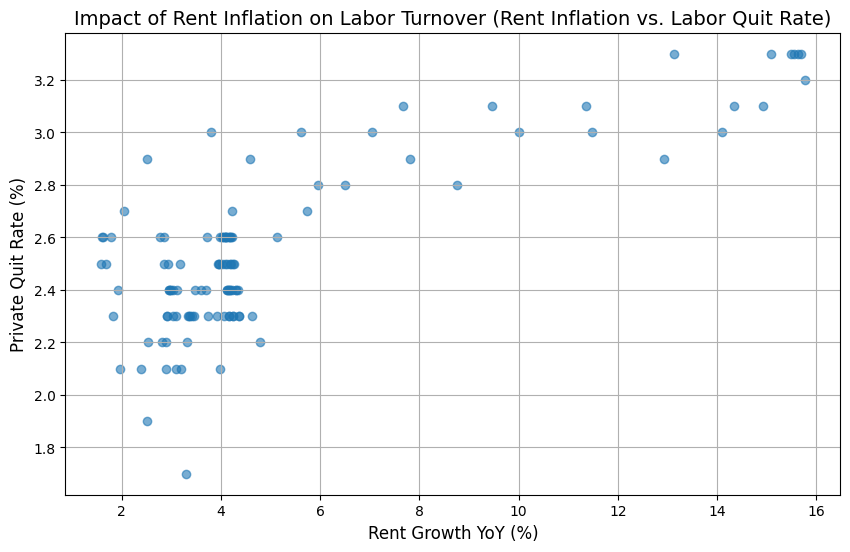

In [ ]:
import matplotlib.pyplot as plt

# 設定畫布大小
plt.figure(figsize=(10, 6))

# 畫散布圖 (x軸: 租金年增率, y軸: 離職率)
plt.scatter(df_final['Rent_Growth_YoY'], df_final['Quit_Rate'], alpha=0.6)

# 設定標題與標籤
plt.title('Impact of Rent Inflation on Labor Turnover (Rent Inflation vs. Labor Quit Rate)', fontsize=14)
plt.xlabel('Rent Growth YoY (%)', fontsize=12)   # x軸：壓力來源
plt.ylabel('Private Quit Rate (%)', fontsize=12)   # y軸：勞動反應
plt.grid(True)

plt.show()

##(4.) 發現與說明

###圖表顯示房租通膨 (Rent Growth YoY) 對勞工離職率 (Private Quit Rate) 有顯著的正向影響。這與 Zabel (2012) 提出的「鎖定效應」（高房價會抑制流動性）相反。
###在房租漲幅溫和（<6%）時，離職率數據高度集中在 2.1% 至 2.6% 之間。然而，當房租年增率突破 8% 時，離職率明顯躍升並維持在 3.0% 以上的高檔區。顯示居住成本的激增可能成為強大的「推力」，迫使勞工透過離職來尋求更高薪資以支付房租，或選擇遷移至生活成本較低的地區，進而推高整體勞動市場的流動率。

#Step 4. 結果驗證

##因果關係與內生性 (OLS & Endogeneity)

###**雙向因果 (Reverse Causality)**：
###=> 我的假設：房租增漲 $\rightarrow$  壓力大 $\rightarrow$ 離職 (Quit)。
###=> 反向可能：離職率高 (代表就業市場流動性好、薪資高) $\rightarrow$ 大家有錢 $\rightarrow$ 房租增漲。

##**Solution**：使用「滯後變數 (Lagged Variable)」：過去的房租，可以影響現在的離職率；但現在的離職率，不可能穿越時空回去影響過去的房租。可有效切斷反向因果。

###**建立滯後變數 (Lag X)，假設房租壓力需要 3 個月才會發酵，反映在離職行動上**

####2015-2020 年間平均失業週數落在 20 至 30 週，但考量平均數易受長期失業極端值影響，改採較能代表典型求職者狀況的「失業週數中位數 (Median Weeks Unemployed)」作為參考指標。根據美國勞工統計局 (BLS) 數據顯示，同期中位數穩定維持於 9 至 10 週（約 2.5 個月）。此求職期間加上離職前的決策與交接緩衝，提供合理的實證依據，將房租壓力傳遞至勞動市場的滯後期設定為一季 (Lag=3)。

####資料來源： U.S. Bureau of Labor Statistics, Average Weeks Unemployed [UEMPMEAN], retrieved from FRED, Federal Reserve Bank of St. Louis. [FRED - Average Weeks Unemployed](https://fred.stlouisfed.org/series/UEMPMEAN)

In [ ]:
import statsmodels.api as sm

# 利用 3 個月前的 房租年增率 (Rent_Growth_YoY) 來預測當月的離職率
df_final['Rent_Growth_Lag3'] = df_final['Rent_Growth_YoY'].shift(3)

# 去除因 shift 而產生的前3筆缺失值
df_renew = df_final.dropna()

X = df_renew['Rent_Growth_Lag3']
y = df_renew['Quit_Rate']

# 手動加入常數項 (截距Intercept)
X = sm.add_constant(X)

# 執行 OLS 回歸
model = sm.OLS(y, X).fit()

# 輸出結果
print(model.summary())
print(f"\n📊 結論: 租金年增率 的 Beta 為 {model.params['Rent_Growth_Lag3']:.4f}")

                            OLS Regression Results                            
Dep. Variable:              Quit_Rate   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                     91.97
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           3.15e-16
Time:                        05:56:50   Log-Likelihood:                 1.4989
No. Observations:                 113   AIC:                             1.002
Df Residuals:                     111   BIC:                             6.457
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.2434      0.039  

##發現與說明
###**實證結果分析** ：透過 OLS 回歸模型檢驗房租通膨對勞動市場的滯後影響。
###結果顯示，解釋變數 Rent_Growth_Lag3 的係數為 0.0602 ，代表兩者呈正相關 ，且 P-value 值高度顯著 ($P < 0.001$)。這意味著房租年增率每上升 1 個百分點，將導致三個月後的離職率上升約 0.06 個百分點。模型 $R^2$ 達到 0.453，顯示 $X_{t-3}$ (過去的房租) 對 $Y_t$ (現在的離職) 有顯著解釋力，居住成本壓力是解釋近期美國離職潮的重要驅動因子。
###**小結** ：透過引入滯後變數有效控制了內生性問題，證實了生活成本上升對勞動力流動具有「推力」效果，而非「鎖定」效果。

#Step 5. 回測與實際應用

##回測：既然確認房租上漲會影響市場，那能否利用這個訊號來投資獲利？

In [ ]:
!pip install yfinance --upgrade --quiet
import yfinance as yf
import numpy as np

In [ ]:
# 取得股價資料 (VNQ: 美國房地產ETF)
ticker = "VNQ"
stock_data = yf.download(ticker, start="2015-01-01", end="2025-08-01", interval="1mo", progress=False)

# 防止 yfinance 新版本傳回多層索引導致錯誤
if isinstance(stock_data.columns, pd.MultiIndex):
    stock_data = stock_data['Close'] # 假設調整後收盤價在 'Close' 下
else:
    stock_data = stock_data[['Close']] # 假設調整後收盤價在 'Close' 下

stock_data = stock_data.reset_index()
stock_data.columns = ['Date', 'Price']

# 日期修正
stock_data['Date'] = stock_data['Date'] + pd.offsets.MonthBegin(-1)

/tmp/ipython-input-528807439.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start="2015-01-01", end="2025-08-01", interval="1mo", progress=False)


In [ ]:
# 合併資料
df_backtest = pd.merge(df_final, stock_data, on='Date', how='inner')
df_backtest

,Date,Rent_Index,Rent_Growth_YoY,Pandemic_Era,Quit_Rate,Quit_Rate_Change,Rent_Growth_Lag3,Price
0,2016-01-01,1220.654055,4.794630,Pre-Covid,2.2,-0.2,NaN,52.036690
1,2016-02-01,1225.406679,4.633955,Pre-Covid,2.3,0.1,NaN,56.846233
2,2016-03-01,1231.413467,4.373643,Pre-Covid,2.3,0.0,NaN,56.131233
3,2016-04-01,1239.311360,4.252904,Pre-Covid,2.3,0.0,4.794630,57.393375
4,2016-05-01,1247.438329,4.163244,Pre-Covid,2.3,0.0,4.633955,60.823112
...,...,...,...,...,...,...,...,...
109,2025-02-01,1917.211710,3.381135,Post-Covid,2.3,0.0,3.100775,87.907875
110,2025-03-01,1929.474463,3.417699,Post-Covid,2.3,0.0,3.193068,86.643112
111,2025-04-01,1938.907827,3.320028,Post-Covid,2.2,-0.1,3.333520,87.614212
112,2025-05-01,1946.045220,3.090711,Post-Covid,2.3,0.1,3.381135,87.359169


In [ ]:
# 計算下個月資產報酬率
df_backtest['Return'] = df_backtest['Price'].pct_change().shift(-1)

In [ ]:
# 建立交易訊號
condition = df_backtest['Rent_Growth_YoY'] > 4
df_backtest['Strategy_Return'] = np.where(condition, df_backtest['Return'], 0)
df_backtest

,Date,Rent_Index,Rent_Growth_YoY,Pandemic_Era,Quit_Rate,Quit_Rate_Change,Rent_Growth_Lag3,Price,Return,Strategy_Return
0,2016-01-01,1220.654055,4.794630,Pre-Covid,2.2,-0.2,NaN,52.036690,0.092426,0.092426
1,2016-02-01,1225.406679,4.633955,Pre-Covid,2.3,0.1,NaN,56.846233,-0.012578,-0.012578
2,2016-03-01,1231.413467,4.373643,Pre-Covid,2.3,0.0,NaN,56.131233,0.022486,0.022486
3,2016-04-01,1239.311360,4.252904,Pre-Covid,2.3,0.0,4.794630,57.393375,0.059758,0.059758
4,2016-05-01,1247.438329,4.163244,Pre-Covid,2.3,0.0,4.633955,60.823112,0.052002,0.052002
...,...,...,...,...,...,...,...,...,...,...
109,2025-02-01,1917.211710,3.381135,Post-Covid,2.3,0.0,3.100775,87.907875,-0.014387,0.000000
110,2025-03-01,1929.474463,3.417699,Post-Covid,2.3,0.0,3.193068,86.643112,0.011208,0.000000
111,2025-04-01,1938.907827,3.320028,Post-Covid,2.2,-0.1,3.333520,87.614212,-0.002911,0.000000
112,2025-05-01,1946.045220,3.090711,Post-Covid,2.3,0.1,3.381135,87.359169,0.010731,0.000000


In [ ]:
# 去除缺失值
df_backtest = df_backtest.dropna()
df_backtest

,Date,Rent_Index,Rent_Growth_YoY,Pandemic_Era,Quit_Rate,Quit_Rate_Change,Rent_Growth_Lag3,Price,Return,Strategy_Return
3,2016-04-01,1239.311360,4.252904,Pre-Covid,2.3,0.0,4.794630,57.393375,0.059758,0.059758
4,2016-05-01,1247.438329,4.163244,Pre-Covid,2.3,0.0,4.633955,60.823112,0.052002,0.052002
5,2016-06-01,1255.583034,4.171064,Pre-Covid,2.3,0.0,4.373643,63.986038,-0.037642,-0.037642
6,2016-07-01,1260.139079,4.059573,Pre-Covid,2.3,0.0,4.252904,61.577457,-0.025064,-0.025064
7,2016-08-01,1262.202151,3.923221,Pre-Covid,2.3,0.0,4.163244,60.034069,-0.050897,0.000000
...,...,...,...,...,...,...,...,...,...,...
108,2025-01-01,1907.881861,3.333520,Post-Covid,2.3,0.2,2.919855,91.170189,-0.035783,0.000000
109,2025-02-01,1917.211710,3.381135,Post-Covid,2.3,0.0,3.100775,87.907875,-0.014387,0.000000
110,2025-03-01,1929.474463,3.417699,Post-Covid,2.3,0.0,3.193068,86.643112,0.011208,0.000000
111,2025-04-01,1938.907827,3.320028,Post-Covid,2.2,-0.1,3.333520,87.614212,-0.002911,0.000000


###利用 cumprod() 計算累積報酬(Cumulative Return)，呈現資產縮水的過程

####意思就是：$1 \times (1 + R_1) \times (1 + R_2) \times (1 + R_3) \dots$
####這代表如果在第一天投入 1 塊錢，現在這筆錢變成了多少。

In [ ]:
# 1 + Return 是把 0.05(賺5%) 變成 1.05(本金變成 1.05 倍)
# cumprod 是 cumulative product (累積連乘)
df_backtest['Cum_Strategy'] = (1 + df_backtest['Strategy_Return']).cumprod()
df_backtest['Cum_Benchmark'] = (1 + df_backtest['Return']).cumprod()

/tmp/ipython-input-3462872031.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_backtest['Cum_Strategy'] = (1 + df_backtest['Strategy_Return']).cumprod()
/tmp/ipython-input-3462872031.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_backtest['Cum_Benchmark'] = (1 + df_backtest['Return']).cumprod()


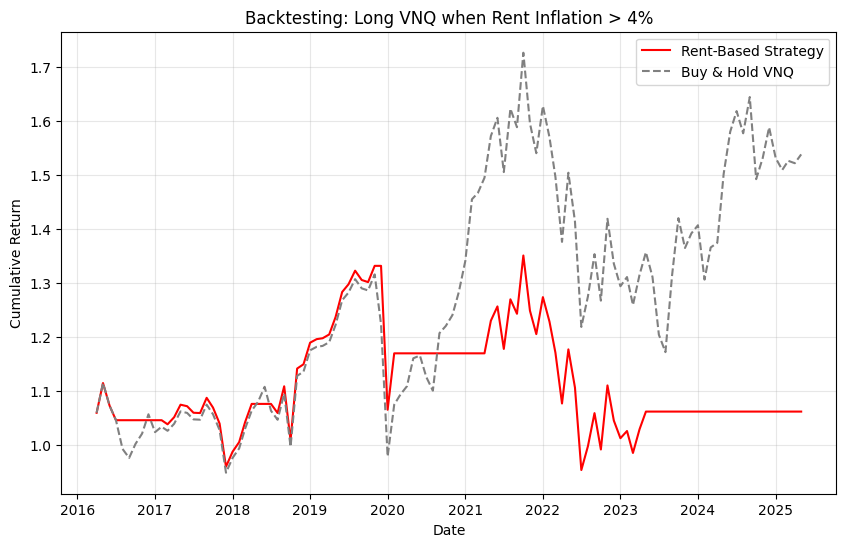

使用策略最終報酬: 1.0619910585241876
持有 VNQ 最終報酬: 1.5384469159830285


In [ ]:
# 繪圖
plt.figure(figsize=(10, 6))
plt.plot(df_backtest['Date'], df_backtest['Cum_Strategy'], label='Rent-Based Strategy', color='red')
plt.plot(df_backtest['Date'], df_backtest['Cum_Benchmark'], label='Buy & Hold VNQ', color='gray', linestyle='--')
plt.title('Backtesting: Long VNQ when Rent Inflation > 4%')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3) # 加網格線
plt.show()

# 數據呈現
print("使用策略最終報酬:", df_backtest['Cum_Strategy'].iloc[-1])
print("持有 VNQ 最終報酬:", df_backtest['Cum_Benchmark'].iloc[-1])

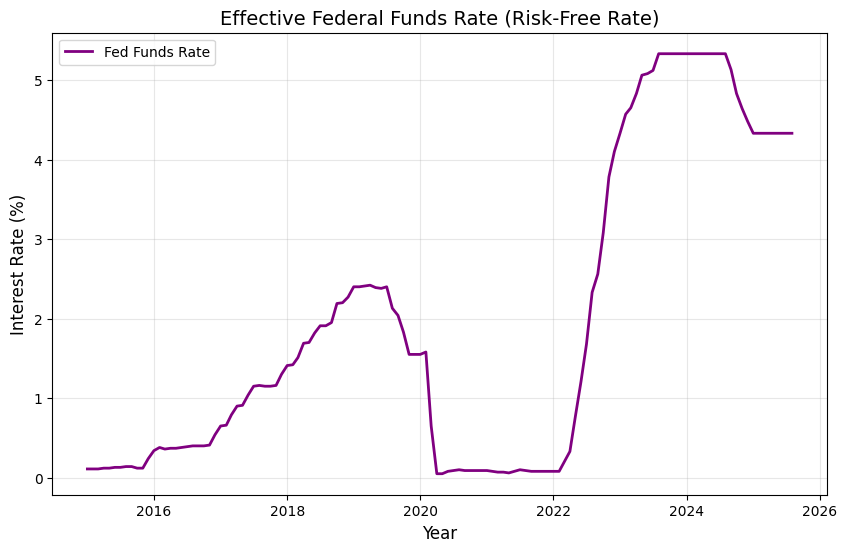

In [ ]:
# 補充聯邦基金利率
!pip install pandas_datareader --quiet
import pandas_datareader.data as web


start_date = '2015-01-01'
end_date = '2025-08-01'

# 抓取聯邦基金利率 (代號: FEDFUNDS)

try:
    df_fed = web.DataReader('FEDFUNDS', 'fred', start_date, end_date)

    plt.figure(figsize=(10, 6))
    plt.plot(df_fed.index, df_fed['FEDFUNDS'], color='purple', linewidth=2, label='Fed Funds Rate')

    plt.title('Effective Federal Funds Rate (Risk-Free Rate)', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Interest Rate (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

except Exception as e:
    print("抓取失敗，請檢查網路連線或 Colab 環境。")
    print(e)

##說明與發現
###回測結果顯示，單純追蹤「租金動能」的投資策略，在 2020 年之前與大盤 (Buy & Hold VNQ) 亦步亦趨。
####然而，自 2022 年起，策略績效出現顯著回撤並隨後停滯，最終累積報酬僅 6.2%，遠低於單純持有 VNQ 的 53.8%。

##核心原因分析 ：通膨的雙面刃 (The Double-Edged Sword of Inflation)

###雖然我們的 OLS 模型準確預測了房租對勞動市場的推力（證明租金上漲是真實的），但投資策略卻遭遇「估值殺手 (Valuation Killer)」—— 利率。

###當租金訊號 (>4%) 叫我們進場時，正值美國通膨最高點。此時聯準會為了打壓通膨，將利率拉升。房地產是對利率極度敏感的資產。利率上升導致折現率 (Discount Rate) 提高，因此即便房東收的租金變多了，房子的資產價格卻因為升息而大跌。

###紅線在 2022 年的大幅修正，正是捕捉到了「高租金」訊號而進場，卻不幸撞上了「升息循環」的結果。這證明了單一因子（只看租金）在面臨系統性風險（利率衝擊）時的脆弱性。

#Step 6. 結論與建議

## 結論
###1. 勞動市場的發現 (OLS)： 實證結果強烈支持「推力假說」。我們發現房租年增率對三個月後的離職率有顯著的正向影響 (Coef=0.06, P<0.001)。這證實了居住成本上升確實構成了巨大的生活壓力，迫使勞工透過離職流動來尋求更高的薪資，而非產生鎖定效應。

###2. 投資策略的反思 (Backtest)： 在投資應用上，我們嘗試利用高租金訊號做多房地產 ETF (VNQ)。然而回測顯示，該策略在 2022 年的高通膨環境下失效。這帶給我們重要的總經啟示：「高租金雖然代表房地產的基本面 (營收) 改善，但在高通膨引發央行激進升息的背景下，利率對資產估值的殺傷力遠大於租金收益的利多。」


## 建議與展望
###如果要完善此策略，不能只看「租金」單一指標。
###未來的研究應考慮加入「利率」：只有在「租金上漲」且「聯準會未激進升息」的環境下，做多房地產才是勝率最高的策略。
###總結而言，不動產投資模型不應僅考量租金收益面 (Income Side)，還必須納入貨幣政策與利率環境 (Monetary Policy) 作為風險控制因子。